In [2]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from numpy import array
from tensorflow.keras.preprocessing.text import one_hot

from keras.models import Sequential
from keras.layers import Activation, Dropout, Dense
from keras.layers import Flatten
from keras.layers import Conv1D
from keras.layers import GlobalMaxPooling1D
from keras.layers import LSTM
from keras.layers import Embedding
from sklearn.model_selection import train_test_split
from keras_preprocessing.text import Tokenizer


In [3]:
movie_reviews = pd.read_csv("IMDB Dataset.csv")


### Dataset dimension

In [4]:
movie_reviews.shape

(50000, 2)

### NULL values

In [5]:
movie_reviews.isnull().sum()

review       0
sentiment    0
dtype: int64

### 5 first lines of the dataset

In [6]:
movie_reviews.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### Check if the dataset is balanced

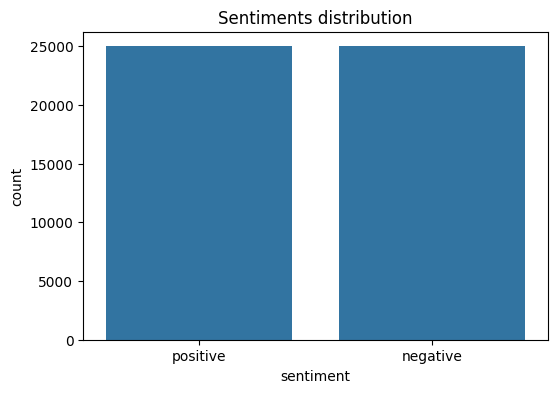

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=movie_reviews)
plt.title("Sentiments distribution")
plt.show()

=> Dataset is balanced: 25000 potive and 25000 negative

### Print the 4th review

In [8]:
movie_reviews['review'][3]

"Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And then we have Jake with his closet which totally ruins all the film! I expected to see a BOOGEYMAN similar movie, and instead i watched a drama with some meaningless thriller spots.<br /><br />3 out of 10 just for the well playing parents & descent dialogs. As for the shots with Jake: just ignore them."

=> On remarque : balises HTML (<br />), ponctuation, chiffres, caractères spéciaux

## PRÉTRAITEMENT DES DONNÉES

In [9]:
TAG_RE = re.compile(r'<[^>]+>')

def remove_tags(text):
    """Supprime toutes les balises HTML du texte."""
    return TAG_RE.sub('', text)

def preprocess_text(sen):
    """
    Nettoie une phrase :
    1) Supprime les balises HTML
    2) Supprime la ponctuation et les chiffres (garde uniquement les lettres)
    3) Supprime les caractères isolés (ex: 's', 'a' seuls)
    4) Supprime les espaces multiples
    """
    sentence = remove_tags(sen)
    sentence = re.sub('[^a-zA-Z]', ' ', sentence)
    sentence = re.sub(r"\s+[a-zA-Z]\s+", ' ', sentence)
    sentence = re.sub(r'\s+', ' ', sentence)
    return sentence

In [10]:
# Appliquer le prétraitement sur toutes les reviews
X = []
sentences = list(movie_reviews['review'])
for sen in sentences:
    X.append(preprocess_text(sen))

### Afficher le 4ème review après prétraitement


In [11]:
X[3]

'Basically there a family where little boy Jake thinks there a zombie in his closet his parents are fighting all the time This movie is slower than soap opera and suddenly Jake decides to become Rambo and kill the zombie OK first of all when you re going to make film you must Decide if its thriller or drama As drama the movie is watchable Parents are divorcing arguing like in real life And then we have Jake with his closet which totally ruins all the film expected to see BOOGEYMAN similar movie and instead watched drama with some meaningless thriller spots out of just for the well playing parents descent dialogs As for the shots with Jake just ignore them '

### Conversion des etiquettes

In [12]:
y = movie_reviews['sentiment']
y = np.array(list(map(lambda x: 1 if x == "positive" else 0, y)))

In [13]:
np.unique(y, return_counts=True)

(array([0, 1]), array([25000, 25000], dtype=int64))

### Division train and test

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

## Embedding Layer

In [15]:
from keras_preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train = tokenizer.texts_to_sequences(X_train)
X_test  = tokenizer.texts_to_sequences(X_test)

In [16]:
vocab_size = len(tokenizer.word_index) + 1
vocab_size

92547

In [17]:
from keras.preprocessing.sequence import pad_sequences
maxlen = 100
X_train = pad_sequences(X_train, padding='post', maxlen=maxlen)
X_test  = pad_sequences(X_test,  padding='post', maxlen=maxlen)

In [18]:
print(f"Shape X_train: {X_train.shape}") 
print(f"Shape X_test : {X_test.shape}")

Shape X_train: (40000, 100)
Shape X_test : (10000, 100)


In [19]:
from numpy import asarray, zeros

embeddings_dictionary = dict()

glove_file = open("glove.6B.100d.txt", encoding="utf8")
for line in glove_file:
    records = line.split()
    word = records[0]
    vector_dimensions = asarray(records[1:], dtype='float32')
    embeddings_dictionary[word] = vector_dimensions
glove_file.close()

In [20]:
print(f"Nombre de mots dans GloVe: {len(embeddings_dictionary)}")


Nombre de mots dans GloVe: 400000


In [21]:
# Création de la matrice d'embeddings (vocab_size x 100)
embedding_matrix = zeros((vocab_size, 100))
for word, index in tokenizer.word_index.items():
    embedding_vector = embeddings_dictionary.get(word)
    if embedding_vector is not None:
        embedding_matrix[index] = embedding_vector

print(f"Embedding matrix shape: {embedding_matrix.shape}")

Embedding matrix shape: (92547, 100)


## A. Classification avec un simple réseau de neurones

In [22]:
model_dense = Sequential([
    Embedding(vocab_size, 100,
              weights=[embedding_matrix],
              input_length=maxlen,
              trainable=False),
    Flatten(),
    Dense(1, activation='sigmoid')
])

model_dense.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['acc']
)
model_dense.summary()

history_dense = model_dense.fit(
    X_train, y_train,
    epochs=6,
    batch_size=128,
    verbose=1,
    validation_split=0.2
)

C:\Program Files\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     9,254,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,254,700 (35.30 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,254,700 (35.30 MB)

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - acc: 0.6755 - loss: 0.5984 - val_acc: 0.7346 - val_loss: 0.5365
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.7622 - loss: 0.4944 - val_acc: 0.7291 - val_loss: 0.5437
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.7823 - loss: 0.4605 - val_acc: 0.7272 - val_loss: 0.5470
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.7960 - loss: 0.4391 - val_acc: 0.7416 - val_loss: 0.5326
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.8096 - loss: 0.4197 - val_acc: 0.7359 - val_loss: 0.5447
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.8131 - loss: 0.4106 - val_acc: 0.7385 - val_loss: 0.5395


### Evaluation du modèle en utilisant evaluate qui renvoie loss et accuracy

In [23]:
score = model_dense.evaluate(X_test, y_test, verbose=1)
print("Test Score:", score[0])
print("Test Accuracy:", score[1]) 

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.7428 - loss: 0.5417
Test Score: 0.5416980385780334
Test Accuracy: 0.7427999973297119


###  Tracer les fonctions de loss et de accuracy pour les training et test sets

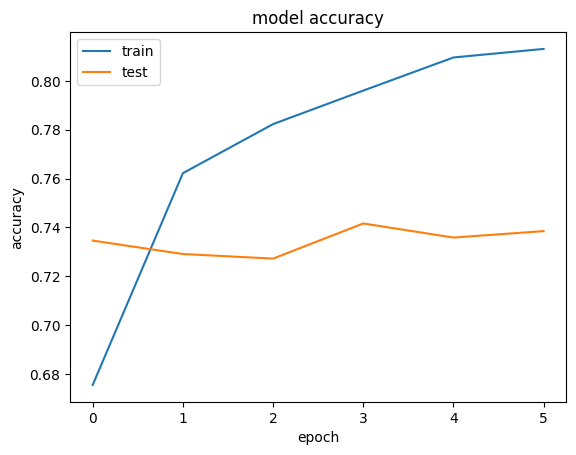

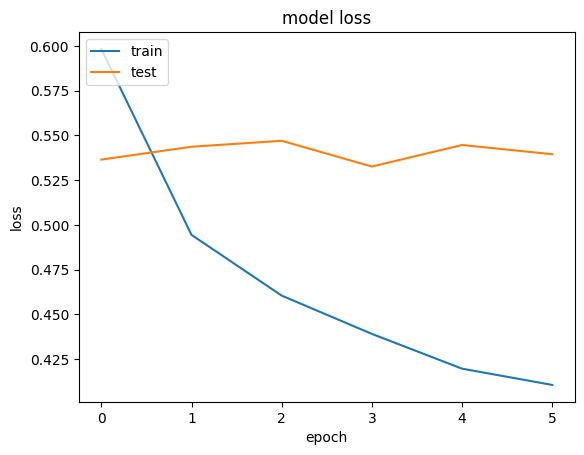

In [24]:
plt.plot(history_dense.history['acc'])
plt.plot(history_dense.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()
plt.plot(history_dense.history['loss'])
plt.plot(history_dense.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

=>  overfitting visible — la train accuracy monte mais val_accuracy stagne

## B.  Classification avec un réseau de neurones convolutionnel

### Création du modèle

In [25]:
model_cnn = Sequential([
    Embedding(vocab_size, 100,
              weights=[embedding_matrix],
              input_length=maxlen,
              trainable=False),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(1, activation='sigmoid')
])

model_cnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['acc']
)
model_cnn.summary()

history_cnn = model_cnn.fit(
    X_train, y_train,
    epochs=6,
    batch_size=128,
    verbose=1,
    validation_split=0.2
)

C:\Program Files\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     9,254,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,254,700 (35.30 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,254,700 (35.30 MB)

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - acc: 0.7474 - loss: 0.5097 - val_acc: 0.8129 - val_loss: 0.4025
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - acc: 0.8393 - loss: 0.3676 - val_acc: 0.8367 - val_loss: 0.3670
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - acc: 0.8675 - loss: 0.3174 - val_acc: 0.8396 - val_loss: 0.3569
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - acc: 0.8875 - loss: 0.2779 - val_acc: 0.8441 - val_loss: 0.3465
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - acc: 0.9061 - loss: 0.2435 - val_acc: 0.8411 - val_loss: 0.3490
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - acc: 0.9219 - loss: 0.2142 - val_acc: 0.8384 - val_loss: 0.3629


### Evaluation 

In [26]:
score_cnn = model_cnn.evaluate(X_test, y_test, verbose=1)
print(f"\nCNN — Test Score   : {score_cnn[0]:.4f}")
print(f"CNN — Test Accuracy: {score_cnn[1]:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.8435 - loss: 0.3585

CNN — Test Score   : 0.3585
CNN — Test Accuracy: 0.8435


### Plots

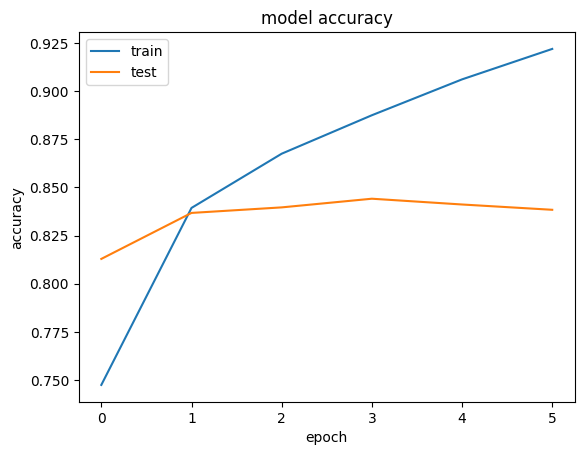

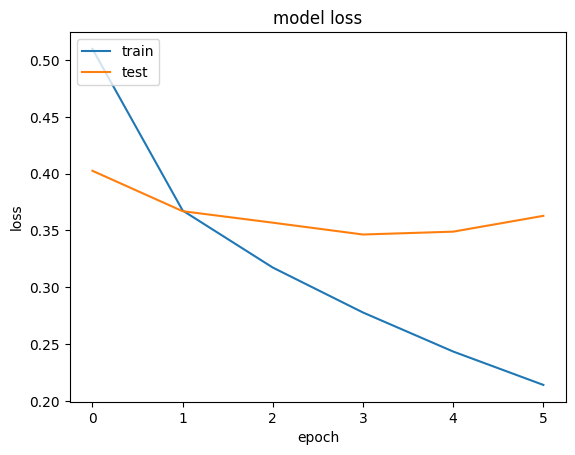

In [27]:
plt.plot(history_cnn.history['acc'])
plt.plot(history_cnn.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()
plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

=> Observation : meilleure généralisation que Dense, détecte les n-grams locaux

## C. Classification avec un réseau de neurones récurrent (LSTM)

In [28]:
model_lstm = Sequential([
    Embedding(vocab_size, 100,
              weights=[embedding_matrix],
              input_length=maxlen,
              trainable=False),
    LSTM(128),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['acc']
)
model_lstm.summary()

history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=6,
    batch_size=128,
    verbose=1,
    validation_split=0.2
)

C:\Program Files\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     9,254,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,254,700 (35.30 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,254,700 (35.30 MB)

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 47s 180ms/step - acc: 0.7037 - loss: 0.5742 - val_acc: 0.7822 - val_loss: 0.4697
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 37s 149ms/step - acc: 0.7730 - loss: 0.4814 - val_acc: 0.8054 - val_loss: 0.4405
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 47s 187ms/step - acc: 0.8101 - loss: 0.4143 - val_acc: 0.8180 - val_loss: 0.3967
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 58s 232ms/step - acc: 0.8295 - loss: 0.3781 - val_acc: 0.8443 - val_loss: 0.3602
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 38s 151ms/step - acc: 0.8452 - loss: 0.3509 - val_acc: 0.8505 - val_loss: 0.3448
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 163ms/step - acc: 0.8503 - loss: 0.3398 - val_acc: 0.8479 - val_loss: 0.3719


### Evaluation

In [29]:
score_lstm = model_lstm.evaluate(X_test, y_test, verbose=1)
print(f"\nLSTM — Test Score   : {score_lstm[0]:.4f}")
print(f"LSTM — Test Accuracy: {score_lstm[1]:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - acc: 0.8442 - loss: 0.3683

LSTM — Test Score   : 0.3683
LSTM — Test Accuracy: 0.8442


### Accuracy and loss plots

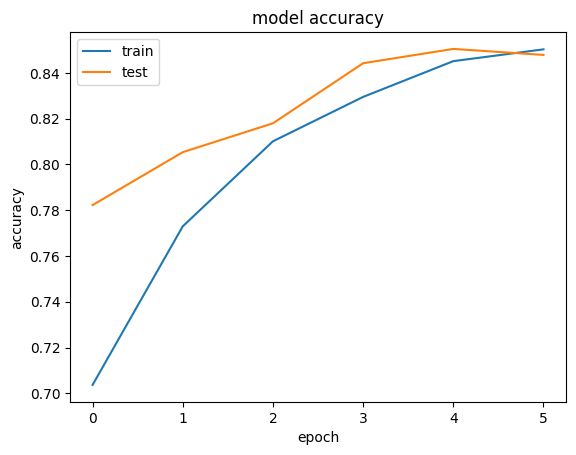

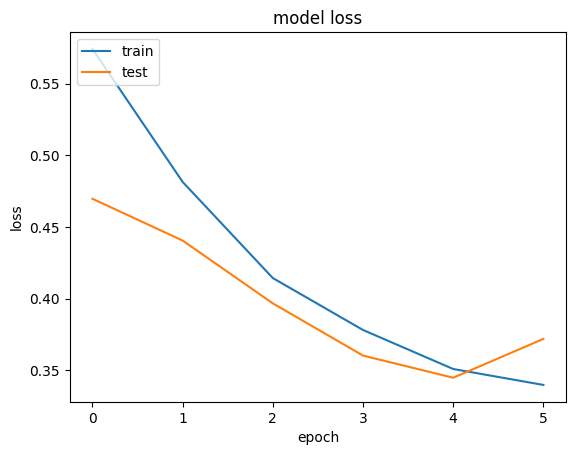

In [30]:
plt.plot(history_lstm.history['acc'])
plt.plot(history_lstm.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()
plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

## Comparison of the 3 classifiers

In [31]:
print("COMPARAISON DES 3 CLASSIFIEURS")
print(f"{'Modèle':<12} {'Test Loss':>12} {'Test Accuracy':>14}")
print(f"{'Dense':<12} {score[0]:>12.4f} {score[1]:>14.4f}")
print(f"{'CNN':<12} {score_cnn[0]:>12.4f}   {score_cnn[1]:>14.4f}")
print(f"{'LSTM':<12} {score_lstm[0]:>12.4f}   {score_lstm[1]:>14.4f}")

COMPARAISON DES 3 CLASSIFIEURS
Modèle          Test Loss  Test Accuracy
Dense              0.5417         0.7428
CNN                0.3585           0.8435
LSTM               0.3683           0.8442


=> LSTM généralement le meilleur sur du texte séquentiel

## Prédire la polarité d'une instance aléatoire
Tester le modèle sur un vrai exemple pour voir s'il prédit correctement.


In [35]:
import random

idx = random.randint(0, len(X_test) - 1)
instance = X_test[idx].reshape(1, -1)
prediction = model_lstm.predict(instance)[0][0]
predicted_label = "POSITIVE " if prediction > 0.5 else "NEGATIVE "
actual_label    = "POSITIVE " if y_test[idx] == 1 else "NEGATIVE "

print(f"\nInstance aléatoire (index {idx})")
print(f"Prédiction  : {predicted_label} (score: {prediction:.4f})")
print(f"Réel        : {actual_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

Instance aléatoire (index 1901)
Prédiction  : NEGATIVE  (score: 0.3370)
Réel        : NEGATIVE 


=> Le modèle n'est pas parfait. Sur des reviews ambigus ou sarcastiques, il peut se tromper. Un score proche de 0.5 indique une incertitude, et un score de 0.68 montre que le modèle hésitait déjà.

## GRU

In [36]:
from keras.layers import GRU
model_gru = Sequential([
    Embedding(vocab_size, 100,
              weights=[embedding_matrix],
              input_length=maxlen,
              trainable=False),
    GRU(128),
    Dense(1, activation='sigmoid')
])
model_gru.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
history_gru = model_gru.fit(
    X_train, y_train, epochs=6, batch_size=128,
    verbose=1, validation_split=0.2
)

C:\Program Files\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 46s 175ms/step - acc: 0.7176 - loss: 0.5346 - val_acc: 0.8081 - val_loss: 0.4235
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 40s 159ms/step - acc: 0.8226 - loss: 0.3928 - val_acc: 0.8385 - val_loss: 0.3621
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 163ms/step - acc: 0.8378 - loss: 0.3620 - val_acc: 0.8420 - val_loss: 0.3555
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 32s 128ms/step - acc: 0.8533 - loss: 0.3367 - val_acc: 0.8478 - val_loss: 0.3446
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 31s 125ms/step - acc: 0.8633 - loss: 0.3153 - val_acc: 0.8536 - val_loss: 0.3288
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 35s 140ms/step - acc: 0.8725 - loss: 0.2966 - val_acc: 0.8570 - val_loss: 0.3219


In [37]:
score_gru = model_gru.evaluate(X_test, y_test, verbose=1)
print(f"GRU — Test Accuracy: {score_gru[1]:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - acc: 0.8600 - loss: 0.3207
GRU — Test Accuracy: 0.8600


## RNN + CNN
On combine deux architectures dans un seul modèle :
Texte → Embedding → CNN → LSTM → Dense → Prédiction
1. Embedding
Convertit chaque mot en vecteur numérique (GloVe)

2. Conv1D (CNN)
Lit le texte par petits groupes de mots 
Détecte des patterns locaux comme :
"not good" → négatif
"very amazing" → positif
Réduit la séquence et extrait les features importantes

3. LSTM (RNN)
Reçoit les features extraites par le CNN
Comprend les dépendances à long terme
Se souvient du contexte sur toute la phrase

4. Dense
Donne le résultat final : 0 ou 1 (négatif/positif)

In [38]:
model_rnn_cnn = Sequential([
    Embedding(vocab_size, 100,
              weights=[embedding_matrix],
              input_length=maxlen,
              trainable=False),
    Conv1D(64, 5, activation='relu'),
    LSTM(64),
    Dense(1, activation='sigmoid')
])
model_rnn_cnn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
history_rnn_cnn = model_rnn_cnn.fit(
    X_train, y_train, epochs=6, batch_size=128,
    verbose=1, validation_split=0.2
)

Epoch 1/6


C:\Program Files\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


250/250 ━━━━━━━━━━━━━━━━━━━━ 31s 101ms/step - acc: 0.6318 - loss: 0.6425 - val_acc: 0.5930 - val_loss: 0.6725
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 92ms/step - acc: 0.6686 - loss: 0.6083 - val_acc: 0.7446 - val_loss: 0.5254
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 80ms/step - acc: 0.7676 - loss: 0.4857 - val_acc: 0.7771 - val_loss: 0.4507
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 44s 172ms/step - acc: 0.8077 - loss: 0.4184 - val_acc: 0.8207 - val_loss: 0.3909
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 48s 194ms/step - acc: 0.8245 - loss: 0.3870 - val_acc: 0.8275 - val_loss: 0.3785
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 72ms/step - acc: 0.8344 - loss: 0.3686 - val_acc: 0.8351 - val_loss: 0.3643


In [39]:
score_rnn_cnn = model_rnn_cnn.evaluate(X_test, y_test, verbose=1)
print(f"RNN+CNN — Test Accuracy: {score_rnn_cnn[1]:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - acc: 0.8329 - loss: 0.3687
RNN+CNN — Test Accuracy: 0.8329


## Tableau Final

In [40]:
print("TABLEAU RÉCAPITULATIF (GloVe uniquement)")
print(f"{'Classifieur':<15} {'Accuracy (GloVe)':>18}")
print("-" * 35)
print(f"{'Dense':<15} {score[1]:>18.4f}")
print(f"{'CNN':<15} {score_cnn[1]:>18.4f}")
print(f"{'LSTM':<15} {score_lstm[1]:>18.4f}")
print(f"{'GRU':<15} {score_gru[1]:>18.4f}")
print(f"{'RNN+CNN':<15} {score_rnn_cnn[1]:>18.4f}")

TABLEAU RÉCAPITULATIF (GloVe uniquement)
Classifieur       Accuracy (GloVe)
-----------------------------------
Dense                       0.7428
CNN                         0.8435
LSTM                        0.8442
GRU                         0.8600
RNN+CNN                     0.8329


Avec GloVe, le GRU est le meilleur classifieur sur ce dataset. Les modèles séquentiels (LSTM, GRU) surpassent le CNN qui lui-même surpasse largement le Dense. Le modèle hybride RNN+CNN nécessiterait plus d'epochs pour exprimer tout son potentiel.